# Insights

- GO Pathway enrichment analysis found 4 statistically significant upregulated and 23 downregulated GO pathways.
- PSMB8 is the only upregulated gene (**18.2 log2FC**) trapped inside an otherwise entirely downregulated "Proteasomal Protein Catabolic Process" pathway.
- PR knockdown appears to broadly affect protein homeostasis, ER stress, trafficking, and ribosome biogenesis, while also producing a specific induction of PSMB8 within an otherwise suppressed proteasomal program.


## 1. Upregulated Pathways 

- When you knocked down PR, top affected pathways for upregulated genes are:

    1. Negative regulation of viral processes (32 genes)
    2. Negative regulation of viral genome replication (26 genes)
    3. Regulation of viral genome replication (28 genes)
    4. Interleukin-27-mediated signaling pathway (6 genes)


## 2. Downregulated Pathways 

- Pathway analysis reveals that in absence of PR, the top 5 affected pathways for downregulated genes are:

    1. Endoplasmic Reticulum to Golgi Vesicle-Mediated Transport (43 genes)
    2. Response to Endoplasmic Reticulum Stress (63 genes)
    3. Proteasomal Protein Catabolic Process (100 genes)
    4. Retrograde Vesicle-Mediated Transport, Golgi to Endoplasmic Reticulum (20 genes)
    5. Intrinsic Apoptotic Signaling Pathway in Response to Endoplasmic Reticulum Stress (17 genes)


In [1]:
import pandas as pd
import gseapy as gp
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# 1. Load pre-saved annotation mapping file
# assuming it has 'gene_id' (Ensembl IDs) and a column named 'symbol' (Gene Symbols)
anno_df = pd.read_csv("gene_annotation_mapping.csv", index_col='gene_id')
anno_df.head()

,symbol,name
gene_id,,
ENSG00000000003,TSPAN6,tetraspanin 6
ENSG00000000419,DPM1,dolichyl-phosphate mannosyltransferase subunit...
ENSG00000000457,SCYL3,SCY1 like pseudokinase 3
ENSG00000000460,FIRRM,FIGNL1 interacting regulator of recombination ...
ENSG00000000938,FGR,"FGR proto-oncogene, Src family tyrosine kinase"


## Gene Ontology Over-Representation Analysis

In [3]:
def run_enrichment_with_index_mapping(file_path, direction_name):
    print(f"\n--- Processing {direction_name} Genes ---")
    
    # Load the differential expression result file (uses gene_id as index)
    deg_df = pd.read_csv(file_path, index_col=0)
    
    # Perform a clean inner join on the indices
    # This aligns the Ensembl IDs perfectly without duplicate rows
    merged_df = deg_df.join(anno_df, how='inner')
    
    # Extract unique, valid gene symbols
    gene_symbols = merged_df['symbol'].dropna().unique().tolist()
    print(f"Matched {len(gene_symbols)} unique gene symbols from {file_path} using index join.")
    
    if len(gene_symbols) == 0:
        print("⚠️ Warning: 0 symbols matched. Double-check the column name in your annotation file!")
        print("Available columns in your annotation file are:", anno_df.columns.tolist())
        return None

    # Run Gene Ontology Over-Representation Analysis (ORA)
    print(f"Querying GO Biological Process database via gseapy...")
    enr = gp.enrichr(
        gene_list=gene_symbols,
        gene_sets=['GO_Biological_Process_2025'],
        organism='human', 
        outdir=None
    )
    
    # Filter for statistically significant pathways (Adjusted P-value < 0.05)
    go_results = enr.results
    sign_pathways = go_results[go_results['Adjusted P-value'] < 0.05]

    #save the significant pathways to output_path
    sign_pathways.to_csv(f"{direction_name}_signGO_pathways.csv", index = False)
    
    print(f"Found {len(sign_pathways)} statistically significant GO pathways.")
    return sign_pathways

In [4]:
# Run the pipeline
up_go = run_enrichment_with_index_mapping("./deseq2_fit/deseq2_results/interaction.up.csv", 
                                          "Upregulated")
down_go = run_enrichment_with_index_mapping("./deseq2_fit/deseq2_results/interaction.down.csv", 
                                            "Downregulated")


--- Processing Upregulated Genes ---
Matched 3758 unique gene symbols from ./deseq2_fit/deseq2_results/interaction.up.csv using index join.
Querying GO Biological Process database via gseapy...
Found 4 statistically significant GO pathways.

--- Processing Downregulated Genes ---
Matched 3127 unique gene symbols from ./deseq2_fit/deseq2_results/interaction.down.csv using index join.
Querying GO Biological Process database via gseapy...
Found 23 statistically significant GO pathways.


## Plot Results

In [5]:
def plot_top_pathways(go_df, title, color):
    if go_df is None or go_df.empty:
        print(f"No significant pathways found to plot for: {title}")
        return
        
    # Grab the top 10 most significant terms
    top_10 = go_df.sort_values(by='Adjusted P-value').head(10).copy()
    top_10['neg_log10_padj'] = -np.log10(top_10['Adjusted P-value'])
    
    # Format pathway descriptions so they don't crowd the y-axis
    top_10['Short_Term'] = top_10['Term'].apply(lambda x: x.split(' (GO:')[0][:50])

    plt.figure(figsize=(9, 5))
    plt.barh(top_10['Short_Term'][::-1], top_10['neg_log10_padj'][::-1], color=color, edgecolor='none')
    
    # Draw statistical significance threshold line (p-adj = 0.05)
    plt.axvline(-np.log10(0.05), color='black', linestyle=':', alpha=0.7, label='p-adj = 0.05')
    
    plt.xlabel('$-\\log_{10}$ Adjusted P-value', fontsize=12)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

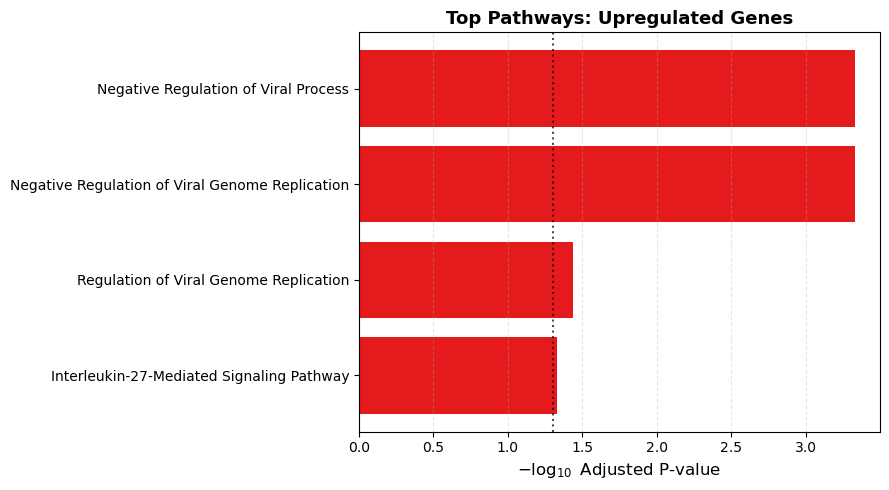

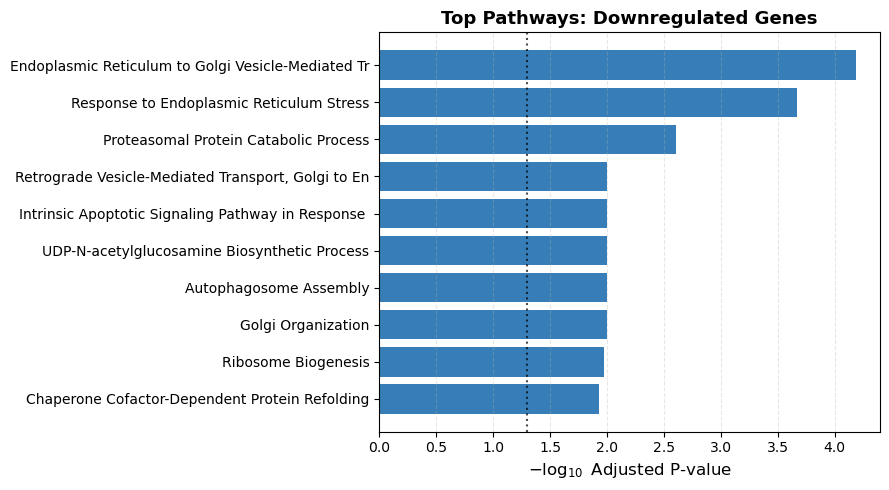

In [6]:
# Generate the plots
plot_top_pathways(up_go, "Top Pathways: Upregulated Genes", "#e41a1c")
plot_top_pathways(down_go, "Top Pathways: Downregulated Genes", "#377eb8")

# Key Insights

- Pathway enrichment analysis reveals what the Progesterone Receptor (PR) knockdown in ER+ cells is affecting these pathways:

## 1. Upregulated Pathways 

- When you knocked down PR, top affected pathways for upregulated genes are:

    1. Negative regulation of viral processes (32 genes)
    2. Negative regulation of viral genome replication (26 genes)
    3. Regulation of viral genome replication (28 genes)
    4. Interleukin-27-mediated signaling pathway (6 genes)

## 2. Downregulated Pathways 

- Pathway analysis reveals that in absence of PR, the top 5 affected pathways for downregulated genes are:

    1. Endoplasmic Reticulum to Golgi Vesicle-Mediated Transport (43 genes)
    2. Response to Endoplasmic Reticulum Stress (63 genes)
    3. Proteasomal Protein Catabolic Process (100 genes)
    4. Retrograde Vesicle-Mediated Transport, Golgi to Endoplasmic Reticulum (20 genes)
    5. Intrinsic Apoptotic Signaling Pathway in Response to Endoplasmic Reticulum Stress (17 genes)

## Extract and Match the Core Pathway Genes

In [7]:
# Load baseline files (Ensure index matches your Ensembl gene_ids)
# Using 'left' or 'inner' join keeps everything perfectly aligned
go_down = pd.read_csv("Upregulated_signGO_pathways.csv", index_col=0)
go_up = pd.read_csv("Downregulated_signGO_pathways.csv", index_col=0)


display(go_up.head(2))
print("\n")
display(go_down.head(2))

,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
Gene_set,,,,,,,,,
GO_Biological_Process_2025,Endoplasmic Reticulum to Golgi Vesicle-Mediate...,42/112,1.435801e-08,0.000065,0,0,3.268006,59.016792,COPB2;ARF4;RAB1A;COPA;SAR1A;SAR1B;PDCD6;COPB1;...
GO_Biological_Process_2025,Response to Endoplasmic Reticulum Stress (GO:0...,60/196,9.587932e-08,0.000216,0,0,2.407555,38.906508,ERO1A;FAF1;CCDC47;BBC3;HERPUD1;SERP1;CHAC1;SEC...


,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
Gene_set,,,,,,,,,
GO_Biological_Process_2025,Negative Regulation of Viral Process (GO:0048525),31/66,1.716296e-07,0.000464,0,0,3.851562,59.999351,IFITM3;RNASEL;IFIT5;IFIT1;OASL;IFI16;CCL5;TRIM...
GO_Biological_Process_2025,Negative Regulation of Viral Genome Replicatio...,25/48,2.186060e-07,0.000464,0,0,4.722568,72.425284,IFITM3;RNASEL;IFIT5;IFIT1;OASL;IFI16;CCL5;TRIM...


In [8]:
# concatenate the two dataframes to create a unified GO dataframe
all_pathways = pd.concat([go_up, go_down], axis=0, ignore_index=True)
all_pathways.head(2)

,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,Endoplasmic Reticulum to Golgi Vesicle-Mediate...,42/112,1.435801e-08,0.000065,0,0,3.268006,59.016792,COPB2;ARF4;RAB1A;COPA;SAR1A;SAR1B;PDCD6;COPB1;...
1,Response to Endoplasmic Reticulum Stress (GO:0...,60/196,9.587932e-08,0.000216,0,0,2.407555,38.906508,ERO1A;FAF1;CCDC47;BBC3;HERPUD1;SERP1;CHAC1;SEC...


In [9]:
deg_df = pd.read_csv("./deseq2_fit/deseq2_results/interaction.significant.csv", index_col=0)
deg_df.head(2)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant,direction
gene_id,,,,,,,,
ENSG00000139998,6037.719954,2.383693,0.054139,44.029086,0.0,0.0,True,up
ENSG00000070495,5060.369649,-3.517828,0.073062,-48.148496,0.0,0.0,True,down


In [10]:
def merge_deg_with_annotation(deg_file, annotation_df, symbol_col: str = "symbol",):
    deg_df = deg_file.copy()
    deg_df = deg_df.reset_index()
    
    if "gene_id" not in deg_df.columns:
        raise ValueError(f"DEG data is missing a 'gene_id' column")

    if symbol_col in deg_df.columns:
        merged = deg_df.copy()
    else:
        annotation_to_merge = annotation_df.reset_index()
        merged = deg_df.merge(annotation_to_merge, on="gene_id", how="left")

    if symbol_col not in merged.columns:
        raise ValueError(
            f"Merged dataframe is missing '{symbol_col}'. Available columns: {list(merged.columns)}"
        )

    return merged

In [11]:
merged_des_df = merge_deg_with_annotation(deg_file = deg_df, annotation_df = anno_df)
merged_des_df.head(2)

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant,direction,symbol,name
0,ENSG00000139998,6037.719954,2.383693,0.054139,44.029086,0.0,0.0,True,up,RAB15,"RAB15, member RAS oncogene family"
1,ENSG00000070495,5060.369649,-3.517828,0.073062,-48.148496,0.0,0.0,True,down,JMJD6,"jumonji domain containing 6, arginine demethyl..."


## Extract Genes

In [12]:
def extract_pathway_genes(go_dataframe, mapped_deg_df, direction_name, outdir="GO_pathway_genes"):
    """
    Loops through the pathways in a GO dataframe, extracts their driving genes,
    and returns a structured dictionary of dataframes containing their DESeq2 statistics.
    Also saves one CSV per pathway into a dedicated output folder.
    """
    if go_dataframe is None or go_dataframe.empty:
        print("❌ Provided GO dataframe is empty.")
        return {}

    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    pathways = go_dataframe.sort_values(by="Adjusted P-value")
    pathway_results = {}

    print(f"========= EXTRACTING GENES FOR THE {direction_name} PATHWAYS =========")

    for _, row in pathways.iterrows():
        full_term_name = row["Term"]
        clean_name = full_term_name.split(" (GO:")[0]

        gene_string = row["Genes"]
        if pd.isna(gene_string) or not isinstance(gene_string, str):
            continue

        pathway_genes = [g.strip() for g in gene_string.split(";")]

        matched_stats = mapped_deg_df[mapped_deg_df["symbol"].isin(pathway_genes)].copy()
        matched_stats = matched_stats.sort_values(by="log2FoldChange", key=abs, ascending=False)

        pathway_results[clean_name] = matched_stats

        safe_name = clean_name.replace(" ", "_").replace("/", "_")
        csv_path = outdir / f"{direction_name}_{safe_name}_genes.csv"
        matched_stats.to_csv(csv_path, index=False)

        print(f"\n📌 Pathway: {clean_name}")
        print(f"🔢 Total Genes Driving Pathway: {len(matched_stats)}")
        print("-" * 65)
        if not matched_stats.empty:
            print(matched_stats[["symbol", "log2FoldChange", "padj"]].head(10).to_string(index=False))
        else:
            print("No matching genes found.")
        print("=" * 65)

    return pathway_results

In [13]:
results = extract_pathway_genes(
    go_dataframe=all_pathways,
    mapped_deg_df=merged_des_df,
    direction_name="all_significant",
    outdir="GO_pathway_genes"
)

========= EXTRACTING GENES FOR THE all_significant PATHWAYS =========

📌 Pathway: Endoplasmic Reticulum to Golgi Vesicle-Mediated Transport
🔢 Total Genes Driving Pathway: 43
-----------------------------------------------------------------
 symbol  log2FoldChange          padj
   ARF4       -3.429080 1.739543e-307
  YIF1A       -2.972203  0.000000e+00
RABGGTB       -2.753986 3.001165e-255
  HYOU1       -2.524016 4.889647e-136
  WHAMM       -2.406021 6.728834e-176
  SEC13       -2.231612  0.000000e+00
   COG3       -2.028098 4.860823e-215
  GOSR2       -1.985031 5.679720e-281
  YIPF4       -1.925252  1.400127e-69
  YIF1B       -1.916693  2.577623e-76

📌 Pathway: Response to Endoplasmic Reticulum Stress
🔢 Total Genes Driving Pathway: 63
-----------------------------------------------------------------
  symbol  log2FoldChange          padj
   DDIT3       -5.972078  0.000000e+00
 HERPUD1       -5.488123  0.000000e+00
    ATF3       -4.857435  0.000000e+00
   HSPA5       -3.839333  0.00000